In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline


In [2]:
df=pd.read_csv('height-weight.csv')

In [3]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


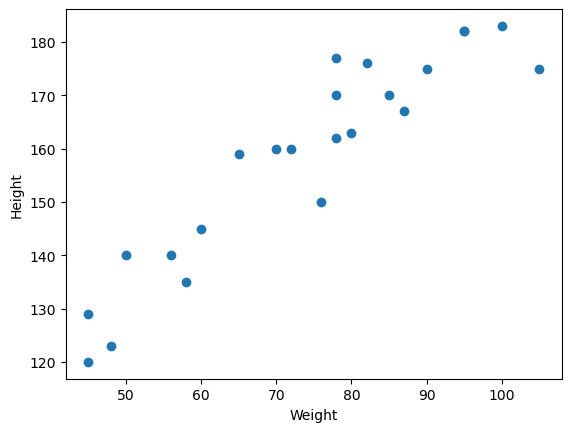

In [4]:
## scatter plot
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel('Height')
plt.show()

In [5]:
## correation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


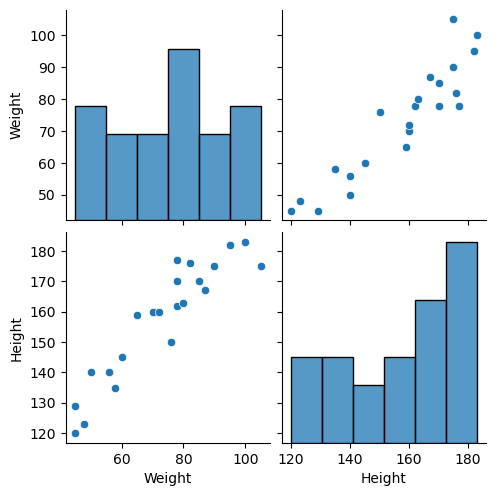

In [6]:
## seaborn for visualization
import seaborn as sns
sns.pairplot(df)
plt.show()

In [7]:
## independent and dependent feature
X=df[['Weight']] ## indendent feature should be dataf frame or 2D
Y=df['Height'] ## this variable can be in series or 1D array
X.head()

,Weight
0,45
1,58
2,48
3,60
4,70


In [8]:
X_series=df['Weight']
np.array(X_series).shape

(23,)

In [9]:
np.array(Y).shape

(23,)

In [10]:
## Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.25,random_state=42)

In [11]:
X_train.shape

(17, 1)

In [12]:
## standardization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_train

array([[-0.87662801],
       [ 1.66773133],
       [ 0.33497168],
       [-1.48242785],
       [ 1.36483141],
       [-1.6641678 ],
       [-0.75546804],
       [-0.1496682 ],
       [ 0.21381171],
       [-1.36126788],
       [-0.99778797],
       [-0.02850823],
       [ 1.06193149],
       [ 0.57729161],
       [ 0.75903157],
       [ 0.88019153],
       [ 0.45613165]])

In [13]:
X_test=scaler.fit_transform(X_test)
X_test

array([[ 0.01711717],
       [ 0.01711717],
       [-1.67748224],
       [ 0.89009262],
       [-0.6504523 ],
       [ 1.40360759]])

In [14]:
## Apply simple linear regresion
from sklearn.linear_model import LinearRegression

In [15]:
regression=LinearRegression(n_jobs=-1)
regression.fit(X_train,Y_train)

LinearRegression(n_jobs=-1)

In [18]:
print('coefficient or sope:',regression.coef_)
print('Intercept:',regression.intercept_)

coefficient or sope: [17.2982057]
Intercept: 156.47058823529412


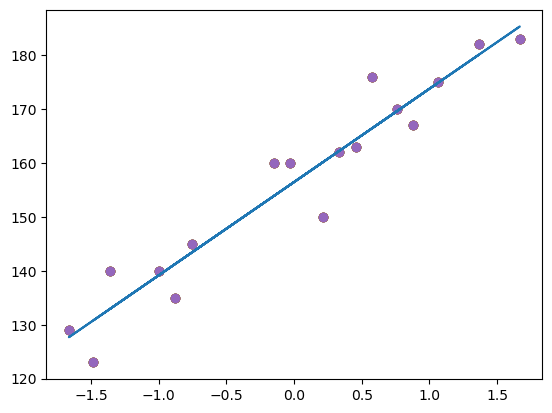

In [24]:
## plot training data plot best fit line
plt.scatter(X_train,Y_train)
plt.plot(X_train,regression.predict(X_train))
plt.show()

In [27]:
## prediction for test data
Y_pred=regression.predict(X_test)


In [28]:
## performace metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [32]:
mse=mean_squared_error(Y_test,Y_pred)
mae=mean_absolute_error(Y_test,Y_pred)
rmse=np.sqrt(mse)
print('mse:',mse)
print('mae:',mae)
print('rmse:',rmse)

mse: 160.95146497458572
mae: 11.76395723317914
rmse: 12.686664848358914


In [33]:
## R square
from sklearn.metrics import r2_score

In [34]:
score=r2_score(Y_test,Y_pred)
print(score)

0.6301147309872273


In [36]:
## Adjusted R square
1-(1-score)*(len(Y_test)-1)/(len(Y_test)-X_test.shape[1]-1)

0.537643413734034

In [41]:
## OLS linear
import statsmodels.api as sm

In [42]:
model=sm.OLS(Y_train,X_train).fit()
prediction=model.predict(X_test)
print(prediction)

[  0.29609625   0.29609625 -29.0174329   15.39700521 -11.25165765
  24.27989283]


In [43]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Thu, 05 Feb 2026   Prob (F-statistic):                       0.664
Time:                        19:08:34   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

C:\Users\nehas\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [48]:
## predition for new data
regression.predict(scaler.transform([[75]]))

C:\Users\nehas\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([154.1018182])